# Vector Data & World Boundaries

A short, hands-on look at reading and drawing vector boundaries with **GeoPandas**, using
two different sources of country outlines — Natural Earth and GADM.

```{admonition} This page is a runnable notebook
:class: tip
Read it here, or click the 🚀 launch button (*"Open in Colab"*) at the top of the page to run
it yourself — no install needed.
```


## 0 · Setup

When running on Colab this installs GeoPandas and downloads the two shapefiles; locally it just finds the bundled `data/` folder.

In [1]:
import sys, os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip -q install geopandas
    import urllib.request
    BASE = "https://raw.githubusercontent.com/tongyuanwu/spatial-tutorial/main/book/data"
    for sub, name in [("ne_110m_admin_0_countries", "ne_110m_admin_0_countries"),
                      ("GADM", "world_from_gadm_100km")]:
        os.makedirs(f"data/{sub}", exist_ok=True)
        for ext in ["shp", "shx", "dbf", "prj", "cpg"]:
            try:
                urllib.request.urlretrieve(f"{BASE}/{sub}/{name}.{ext}", f"data/{sub}/{name}.{ext}")
            except Exception:
                pass

def find_data_dir(start=None):
    start = start or Path.cwd()
    for p in [start, *start.parents]:
        if (p / "data").is_dir():
            return p / "data"
    return Path("data")

DATA_DIR = find_data_dir()
print("Using DATA_DIR =", DATA_DIR)

Using DATA_DIR = D:\wty\Documents\GitHub\spatial-tutorial\book\data


In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

## 1 · Natural Earth boundaries

`geopandas.read_file` loads a shapefile into a **GeoDataFrame** — a table whose rows are
features and whose `geometry` column holds the shapes. Plotting is then a single call.


177 features | CRS: EPSG:4326


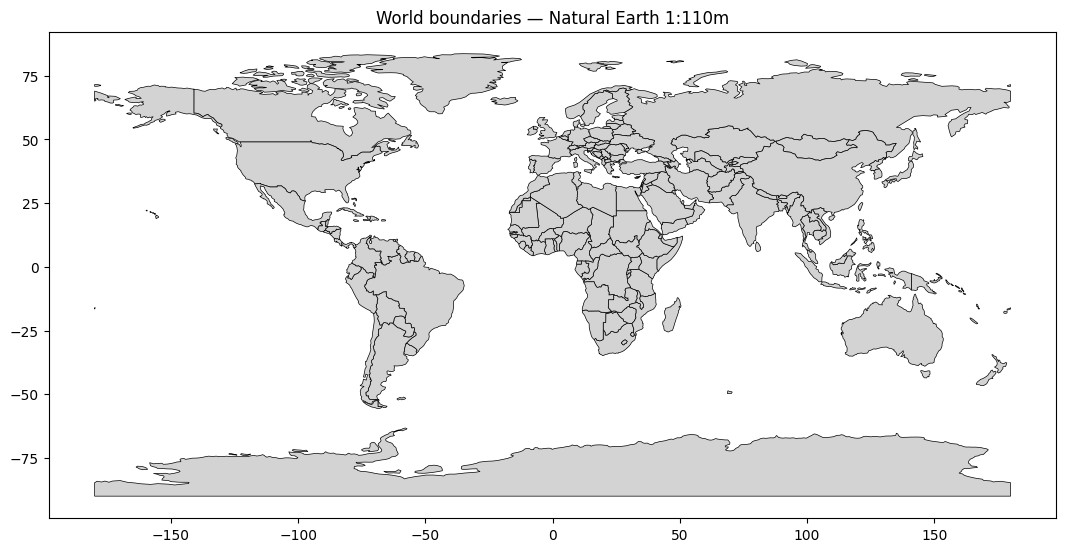

In [3]:
world = gpd.read_file(DATA_DIR / "ne_110m_admin_0_countries" / "ne_110m_admin_0_countries.shp")
print(f"{len(world)} features | CRS: {world.crs.to_string()}")

fig, ax = plt.subplots(figsize=(13, 7))
world.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.5)
ax.set_title("World boundaries — Natural Earth 1:110m")
plt.show()

## 2 · GADM boundaries

[GADM](https://gadm.org/) is a database of global administrative areas. Here we read a
world layer that has been generalized to ~100 km, and plot it the same way. The two sources
differ in detail and in how they treat borders — useful to know when you pick a basemap.


C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: D:\wty\Documents\GitHub\spatial-tutorial\book\data\GADM\world_from_gadm_100km.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


263 features | CRS: EPSG:4326


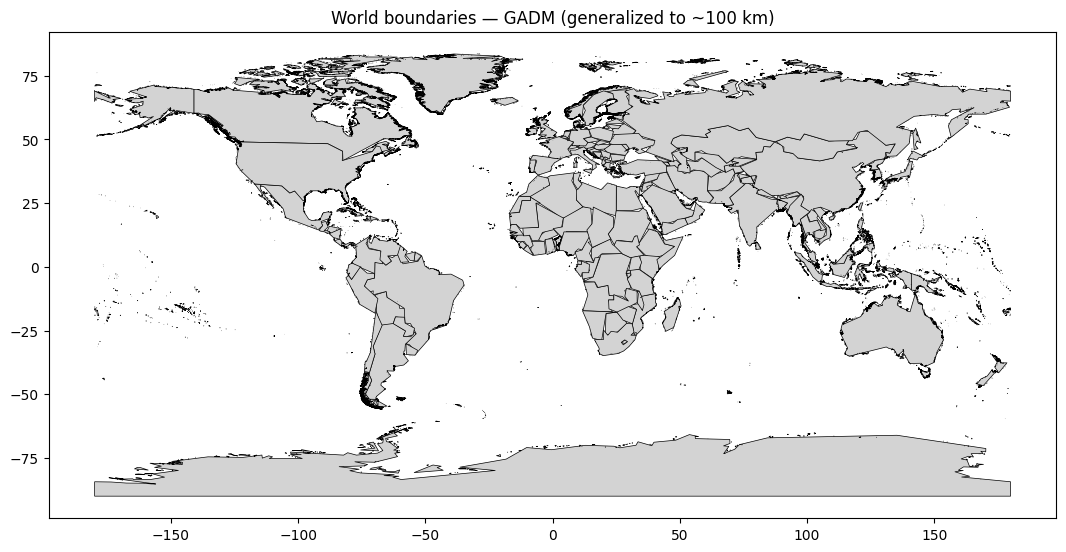

In [4]:
gadm = gpd.read_file(DATA_DIR / "GADM" / "world_from_gadm_100km.shp")
print(f"{len(gadm)} features | CRS: {gadm.crs.to_string()}")

fig, ax = plt.subplots(figsize=(13, 7))
gadm.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.5)
ax.set_title("World boundaries — GADM (generalized to ~100 km)")
plt.show()

```{admonition} Deliverable
:class: note
You can load a shapefile into a GeoDataFrame, inspect its CRS, and draw country boundaries
from two different global sources.
```

**Next:** boundaries are most useful *on top of* data — see how raster and vector layers
combine in [](../viz/08-species-richness.ipynb).
